In [1]:
from platform import python_version
print(python_version())

3.11.14


### Calculating DEGs statistics

### For each LFC/FDR cutoff set, we get a different set of DEGs
  - LFC: LFC cutoff and FDR_LFC cutoff
  - Pathway: fdr and pval pathway cutoff and min num of genes

### Up and Down DEGs simulation
  - Up and Down DEGs/DAPs
  - Up and Down in pathways

### there are 2 statistical tables
  - pval/fdr cutoff x degs
  - pval/fdr/geneset/quantile degs_in_pathway, num_pathways

In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

sys.path.insert(1, '../src/')

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import *
from libs.MTD_lib import MTD
from libs.GDC_lib import GDC
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config

from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'TCGA-BRCA'
PSI_ID = 'TCGA-ACC'
PSI_ID = 'TCGA-CESC'
PSI_ID = 'TCGA-PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD/config/all_lfc_cutoffs_TCGA-PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/TCGA-PAAD
>>> Tumor
>>> case Tumor
	DEGs 19572
		Up (#9553)
		Dw (#10019)

Up-regulated per biotype
                               biotype     n
0                            IG_C_gene    13
1                      IG_C_pseudogene     2
2                            IG_J_gene    11
3                      IG_J_pseudogene     1
4                            IG_V_gene   122
5                      IG_V_pseudogene    42
6                              Mt_tRNA    13
7                                  TEC    96
8                            TR_C_gene     6
9                            TR_D_gene     1
10                           TR_J_gene     9
11                           TR_V_gene    43
12                     TR_V_pseudogene     2
13                              lncRNA  3139
14                               miRNA    77
15                            misc_RNA    15
16              polymorphic_pseudogene     4
17        

In [5]:
gdc = GDC(root0=ROOT0, root0_data=ROOT0_DATA)

gdc.memory_restriction = False

### Get all programs

In [ ]:
force = False
verbose = False

prog_list = gdc.get_gdc_progams(force=force, verbose=verbose)

df_psi = gdc.get_primary_sites(prog_id=PROG_ID, verbose=verbose)
print(len(df_psi))
df_psi.head(3)

33


((33, 5),
 Index(['psi_id', 'primary_site', 'project_id', 'disease_type', 'name'], dtype='object'))

In [7]:
gdc.set_primary_site(psi_id=PSI_ID, verbose=verbose)

True

In [8]:
verbose=False
force=False

imax_samples = 200

df_tumor, df_normal, df_gtex_ctrl = gdc.calc_file_expression_tumor_normal_gtex(
            imax_samples=imax_samples, force=force, verbose=verbose)

print(len(df_tumor), len(df_normal), len(df_gtex_ctrl))
df_tumor.head(3)


43342 60660 74628


,geneid,symbol,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,...,tumor_23,tumor_24,tumor_25,tumor_26,tumor_27,tumor_28,tumor_29,tumor_30,tumor_31,tumor_32
0,ENSG00000000003,TSPAN6,1644.0,622.0,839.0,618.0,643.0,728.0,800.0,856.0,...,1060.0,1221.0,210.0,18.0,155.0,36.0,84.0,182.0,323.0,192.0
1,ENSG00000000005,TNMD,5.0,1.0,0.0,64.0,4.0,0.0,0.0,1.0,...,0.0,1.0,87.0,4.0,2.0,0.0,1.0,8.0,1.0,0.0
2,ENSG00000000419,DPM1,985.0,782.0,956.0,674.0,297.0,633.0,1019.0,994.0,...,1056.0,843.0,474.0,711.0,493.0,744.0,528.0,457.0,447.0,524.0


In [9]:
df_normal.head(3)

,geneid,symbol,normal_1
0,ENSG00000000003,TSPAN6,1897
1,ENSG00000000005,TNMD,2
2,ENSG00000000419,DPM1,762


In [10]:
df_gtex_ctrl.head(3)

,ensemblid,symbol,GTEX-1JMLX-1726-SM-HL9TG,GTEX-15ER7-1326-SM-6LPK9,GTEX-11EQ9-1026-SM-5H134,GTEX-1B996-1326-SM-731EO,GTEX-11GSP-0426-SM-5A5KX,GTEX-11ONC-0526-SM-5BC57,GTEX-1IL2U-2326-SM-CNNQV,GTEX-15DYW-1626-SM-6LLI1,GTEX-13O1R-1826-SM-5KM3B,GTEX-S33H-1226-SM-4AD69,GTEX-1B933-1726-SM-731FC,GTEX-18A7A-1726-SM-7LT93,GTEX-14PJM-2126-SM-6AJAS,GTEX-14C39-1026-SM-5P9IG,GTEX-18A6Q-1726-SM-7LT9A
0,ENSG00000290825.2,DDX11L16,0,0,1,1,1,0,1,1,0,0,1,0,0,0,1
1,ENSG00000223972.6,DDX11L1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,ENSG00000310526.1,WASH7P,184,96,193,74,65,73,316,122,170,232,156,115,61,255,151


### Data treatment

1. get raw dfc
2. filter low-expression genes
3. normalize for library size
4. variance-stabilizing transformation
5. select most variable genes
6. cluster samples into k = 3..8 groups
7. evaluate clusters
8. find gene signatures for each cluster

A low-expression gene can be biologically important and even differentially expressed, especially if it is a transcription factor, cytokine, receptor, lncRNA, or rare-cell marker.

But for unsupervised tumor clustering, we usually do not want thousands of genes with mostly zero/very low counts because they add noise and unstable distances.

In [11]:
df_sel, df_cpm,  dfg_filt, df_scaled = gdc.cluster_data(df_tumor=df_tumor, perc_min_samples = 0.25, top_n = 5_000)

sample_cols 32 and min_samples


In [12]:
df_pca = gdc.calc_PCA(df_scaled, n_components=10, verbose=False)
df_pca.head(3)

,PC1,PC2,PC3
tumor_1,17.992,15.124,-23.627
tumor_2,15.547,24.725,-12.311
tumor_3,3.353,4.853,57.367


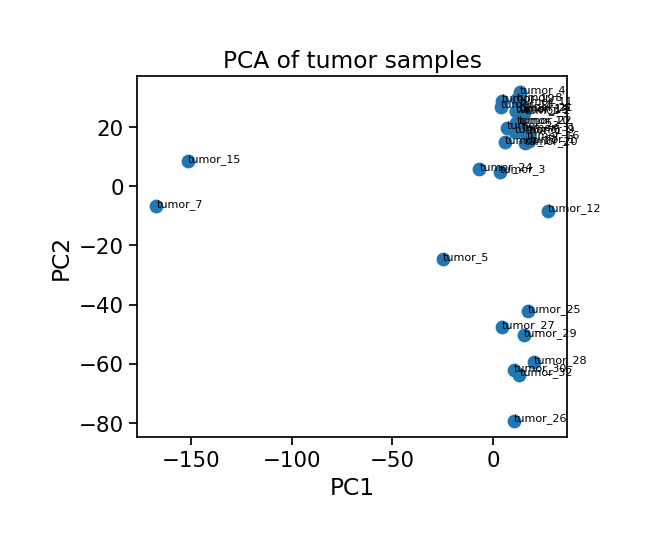

In [13]:
gdc.plot_PCA(df_pca)

In [14]:
df_eval, df_samp_clusters = gdc.calc_best_cluster(df_pca, min_clusters=3, max_clusters=8)
df_eval

,k,silhouette
0,3,0.653
1,4,0.445
2,5,0.415
3,6,0.535
4,7,0.529
5,8,0.465


In [16]:
df_samp_clusters.head(6)

,sample,cluster
0,tumor_1,1
1,tumor_2,1
2,tumor_3,1
3,tumor_4,1
4,tumor_5,3
5,tumor_6,1


### PCA-UMAP

In [49]:
n_neighbors=3
min_dist=0.2

df_umap = gdc.calc_PCA_UMAP(df_pca, df_samp_clusters, n_neighbors=n_neighbors, min_dist=min_dist, metric="euclidean")
print(df_umap.cluster.unique())
df_umap.head(3)

[1 3 2]


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,UMAP1,UMAP2,sample,cluster
0,18.610,8.108,tumor_1,1
1,18.386,6.780,tumor_2,1
2,11.116,7.689,tumor_3,1


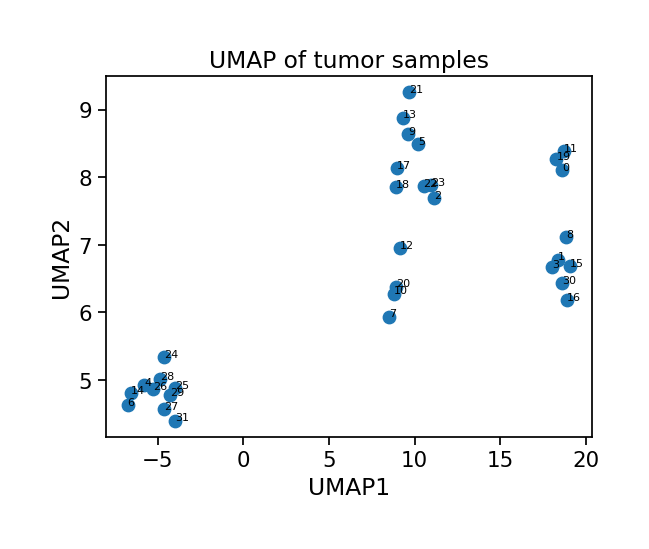

In [ ]:
gdc.plot_PCA_UMAP(df_umap, n_neighbors=n_neighbors, min_dist=min_dist, figsize=(6, 5))

### Hierarchical clustering alternative

For 32 samples, this is often better than UMAP.

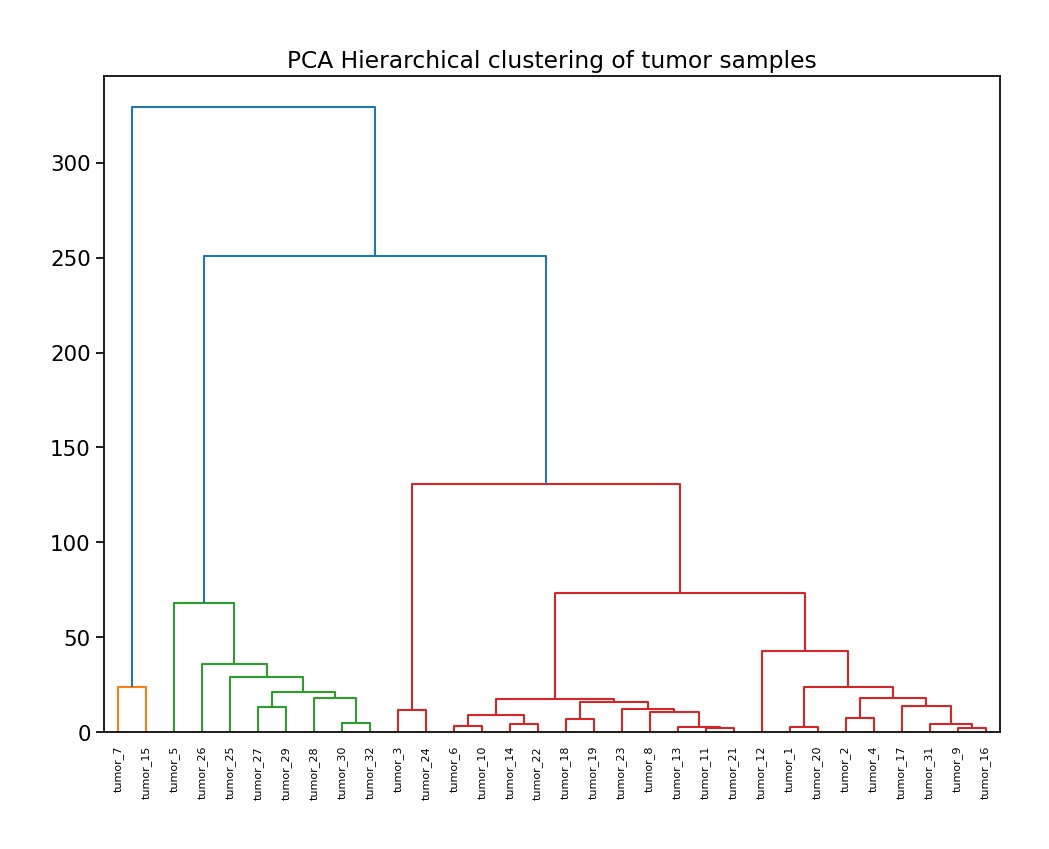

In [30]:
gdc.plot_HCA_PCA(df_pca, figsize=(10, 8))

In [25]:
# Cut tree into k clusters

df_cluster_hca = gdc.cut_HCA_PCA(df_pca=df_pca, n_clusters=3, method="ward", criterion="maxclust", verbose=True)
df_cluster_hca.head(6)

cluster
1     2
2     8
3    22
dtype: int64


,sample,cluster
0,tumor_1,3
1,tumor_2,3
2,tumor_3,3
3,tumor_4,3
4,tumor_5,2
5,tumor_6,3


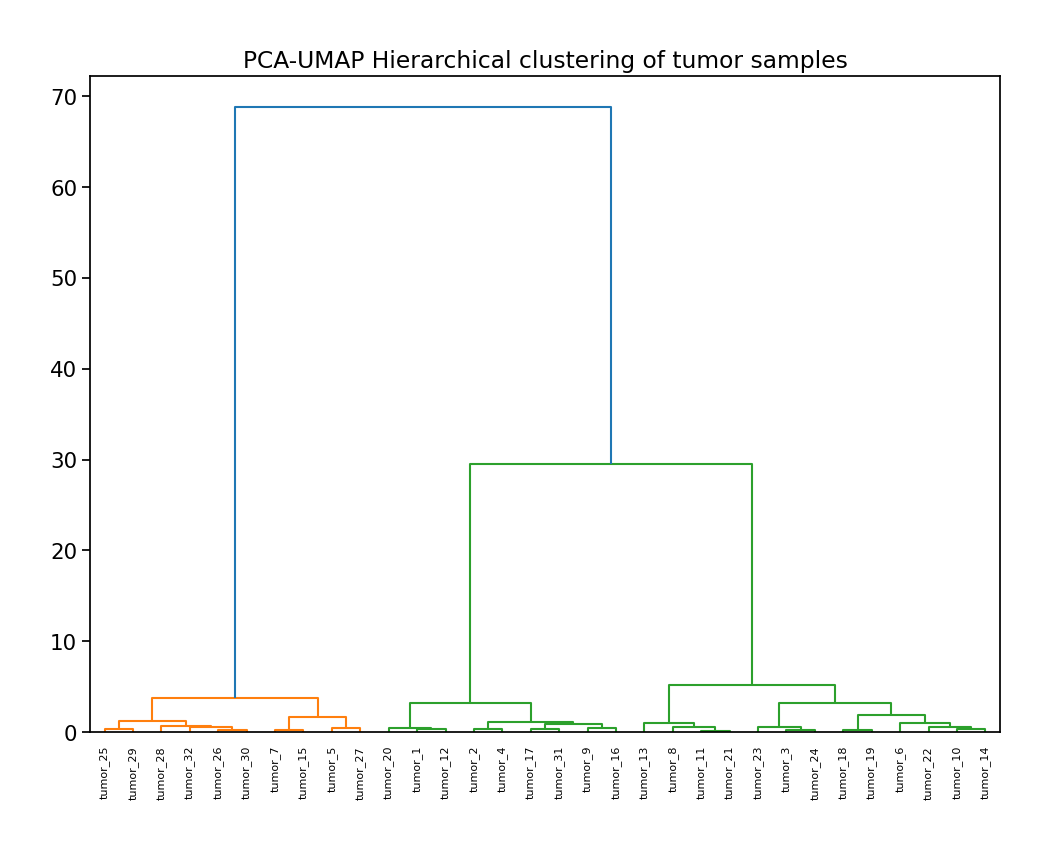

In [29]:
gdc.plot_HCA_PCA_UMAP(df_umap, figsize=(10, 8))

In [32]:
# Cut tree into k clusters

df_cluster_umap = gdc.cut_HCA_PCA_UMAP(df_umap=df_umap, n_clusters=3, method="ward", criterion="maxclust", verbose=True)
df_cluster_umap.head(6)

cluster
1    10
2     9
3    13
dtype: int64


,sample,cluster
0,tumor_1,2
1,tumor_2,2
2,tumor_3,3
3,tumor_4,2
4,tumor_5,1
5,tumor_6,3


### Define cluster marker genes

This finds genes high in one cluster compared with all others.

In [33]:
gene_annot = (
    dfg_filt[["geneid", "symbol"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

### cluster signatures

In [36]:
df_cpm.head(2)

,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,tumor_10,...,tumor_23,tumor_24,tumor_25,tumor_26,tumor_27,tumor_28,tumor_29,tumor_30,tumor_31,tumor_32
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,48.025,23.425,31.902,29.447,27.146,24.728,63.884,22.840,44.762,78.125,...,31.642,43.658,8.822,0.700,7.543,1.227,4.084,7.050,16.464,8.174
ENSG00000000419,28.774,29.450,36.351,32.115,12.539,21.501,81.372,26.522,22.258,39.196,...,31.523,30.142,19.913,27.636,23.992,25.357,25.673,17.703,22.784,22.308


In [37]:
dfc_log = np.log2(df_cpm + 1)
dfc_log.head(2)

,tumor_1,tumor_2,tumor_3,tumor_4,tumor_5,tumor_6,tumor_7,tumor_8,tumor_9,tumor_10,...,tumor_23,tumor_24,tumor_25,tumor_26,tumor_27,tumor_28,tumor_29,tumor_30,tumor_31,tumor_32
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,5.615,4.610,5.040,4.928,4.815,4.685,6.020,4.575,5.516,6.306,...,5.029,5.481,3.296,0.765,3.095,1.155,2.346,3.009,4.126,3.198
ENSG00000000419,4.896,4.928,5.223,5.049,3.759,4.492,6.364,4.783,4.540,5.329,...,5.023,4.961,4.386,4.840,4.643,4.720,4.737,4.225,4.572,4.543


In [38]:
dfc_log = np.log2(df_cpm + 1)

dfall, dfsig = gdc.find_cluster_signature_genes(df_logcpm=dfc_log, df_samp_clusters=df_samp_clusters, gene_annot=gene_annot, lfc_cutoff=1.0, fdr_cutoff=0.05,)

In [39]:
dfall.head(3)

,geneid,cluster,n_in,n_out,mean_in,mean_out,lfc,pvalue,fdr,symbol
0,ENSG00000196188,1,22,10,8.801,0.786,8.015,2.247e-14,1.078e-10,CTSE
1,ENSG00000196878,1,22,10,8.641,1.414,7.227,9.524e-12,9.773e-09,LAMB3
2,ENSG00000215182,1,22,10,7.277,0.072,7.205,1.303e-10,8.935e-08,MUC5AC


In [43]:
dfsig.cluster.unique()

array([1, 2, 3], dtype=int32)

In [ ]:
dfclu = gdc.write_clusters(dfall, dfsig, LFC_cutoff=3., FDR_cutoff=0.01, verbose=False)

dfclu

,ncluster,ngenes,genes
0,1,2098,"[CTSE, LAMB3, MUC5AC, LGALS4, TACSTD2, DMBT1, KRT19, S100A14, MUC1, SFN, PIG..."
1,2,990,"[CEACAM5, CRP, MSLN, COL17A1, GPRC5A, CLDN18, KLK10, KRT17, TMPRSS4, KRT7, M..."
2,3,1266,"[CHGB, CPLX2, CHGA, PCSK2, APLP1, TTR, ABCC8, TMEM63C, PTPRN, PCSK1N, SEZ6L,..."


### CALC_DEGS -> build_counts_and_metadata()

In [ ]:
cdegs = CALC_DEGS(root_src=gdc.root_src, run_conda=False)
gdc.cdegs = cdegs

verbose=True
df_tumor, df_normal, msg = gdc.get_tumor_normal_tables(verbose=verbose)

In [ ]:
df_tumor.head(3)

In [ ]:
df_normal.head(3)

In [ ]:
df_counts, df_meta = cdegs.build_counts_and_metadata(
            df_tumor=df_tumor,
            df_normal=df_normal,
            how="inner"
        )

df_counts.head(3)

In [ ]:
df_meta

In [ ]:
dff, normal_samples, tumor_samples = build_df_exp_and_filter(df_counts=df_counts, df_meta=df_meta,
    gene_col = "geneid",
    equal_var = False,)   # False = Welch t-test, safer when n differs

print(len(df_counts), len(dff))

dff.head(3)

In [ ]:
import seaborn as sns

In [ ]:
cols = ['geneid'] + normal_samples + tumor_samples

dff2 = dff[cols].copy()
dff2.set_index('geneid', inplace=True)
dff2.head(3)

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import zscore

figsize = (12,8)

title = 'Hierarchical Clustering of Expression Data'

# numeric matrix
dff2 = dff2.apply(pd.to_numeric, errors="coerce").fillna(0)
mat = np.log2(dff2 + 1)

# gene-wise z-score using pandas/numpy
row_mean = mat.mean(axis=1)
row_std = mat.std(axis=1)

mat_z = mat.sub(row_mean, axis=0).div(row_std.replace(0, np.nan), axis=0)
mat_z = mat_z.replace([np.inf, -np.inf], np.nan).fillna(0)

cg = sns.clustermap(
    mat_z,
    metric="correlation",
    method="average",
    figsize=figsize,
    cmap="viridis",
    cbar=True,
)

title = "Hierarchical Clustering of Expression Data"
cg.figure.suptitle(title, y=1.02)

plt.show()


In [ ]:
mat_z

### Development & tests

In [ ]:
def get_representative_geneids(
    dfs: list[pd.DataFrame],
    min_fraction: float = 0.75,
) -> pd.DataFrame:
    """
    Return genes present in more than min_fraction of dataframes.

    For 10 dataframes and min_fraction=0.75:
    strict >75% means present in at least 8 dataframes.

    Presence is counted once per dataframe, even if duplicated inside a dataframe.
    """

    gene_cols: list[str] = ["geneid", "symbol"]

    n = len(dfs)
    if n == 0:
        return pd.DataFrame(columns=gene_cols + ["n_dfs", "fraction"])

    min_count = math.floor(n * min_fraction) + 1  # strict > min_fraction

    counter = Counter()

    for df in dfs:
        missing = [c for c in gene_cols if c not in df.columns]
        if missing:
            raise ValueError(f"Missing columns in dataframe: {missing}")

        genes_in_df = (
            df[gene_cols]
            .dropna(subset=gene_cols)
            .astype(str)
            .drop_duplicates()
        )

        counter.update(map(tuple, genes_in_df.to_numpy()))

    result = (
        pd.DataFrame(
            [(geneid, symbol, count) for (geneid, symbol), count in counter.items()],
            columns=gene_cols + ["n_dfs"],
        )
        .assign(fraction=lambda x: x["n_dfs"] / n)
        .query("n_dfs >= @min_count")
        .sort_values(["n_dfs"] + gene_cols, ascending=[False] + [True] * len(gene_cols))
        .reset_index(drop=True)
    )

    return result

In [ ]:
df_list = []

cols = ["geneid", "symbol", "biotype", "dfc"]


i = 0
for _, dfa in dic_tumor.items():
    if dfa is None or dfa.empty:
        continue

    i += 1
    # print(i, end=' ')
    if "gene_id" in dfa.columns:
        dfa = dfa.rename(columns={"gene_id": "geneid"})
    if "gene_type" in dfa.columns:
        dfa = dfa.rename(columns={"gene_type": "biotype"})

    dfa = dfa[cols]
    df_list.append(dfa)

In [ ]:
dfq = gdc.get_representative_geneids(df_list, min_fraction=0.75)

print(len(dfq))

dfq.head(3)

In [ ]:
lista = np.unique(dfq.geneid.to_list())
print(len(lista))
lista[:3]

In [ ]:
df_tumor = pd.DataFrame()

cols = ["geneid", "symbol", "dfc"]
common_cols = ["geneid", "symbol"]

imax_tumor=50

i = 0
for _, dfa in dic_tumor.items():
    if dfa is None or dfa.empty:
        continue

    i += 1
    # print(i, end=' ')
    if "gene_id" in dfa.columns:
        dfa = dfa.rename(columns={"gene_id": "geneid"})
    if "gene_type" in dfa.columns:
        dfa = dfa.rename(columns={"gene_type": "biotype"})

    dfa = dfa[cols]

    dfa = (
        dfa.dropna(subset=['geneid', 'symbol'])
        .drop_duplicates(['geneid', 'symbol'])
    )

    dfa = dfa.rename(columns={"dfc": f"tumor_{i}"})


    dfa = dfa[dfa.geneid.isin(lista)]
    dfa.reset_index(drop=True, inplace=True)

    if df_tumor.empty:
        df_tumor = dfa
    else:
        if i <= imax_tumor:
            df_tumor = df_tumor.merge(dfa, on=common_cols, how="outer")
            print(i, dfa.shape, df_tumor.shape)
        else:
            if verbose:
                print(">>> dfa", len(dfa), ",".join(dfa.symbol[:30]))
            break


In [ ]:
df_tumor.head(3)

In [ ]:
pdwritecsv(df_tumor, 'PPAD_tumor_expression.tsv', verbose=True)

### Cluster

In [ ]:
gene_cols = ["geneid", "symbol"]
sample_cols = [c for c in df_tumor.columns if c not in gene_cols]

dfc = (
    df_tumor[sample_cols]
    .apply(pd.to_numeric, errors="coerce")  # non-numeric -> NaN
    .fillna(0)                              # NaN -> 0
).copy()

dfg = df_tumor[gene_cols].copy()

dfc.index = df_tumor["geneid"]

# filter low-count genes
min_samples = int(0.25 * len(sample_cols))

print(f"sample_cols {len(sample_cols)} and min_samples")

keep = list ((dfc >= 10).sum(axis=1) >= min_samples)

dfc_filt = dfc.loc[keep]
dfg_filt = dfg.loc[keep]

print(dfc_filt.shape)

# normalize by library size

library_sizes = dfc_filt.sum(axis=0)

df_cpm = dfc_filt.div(library_sizes, axis=1) * 1_000_000

In [ ]:
df_cpm

In [ ]:
dfc_log = np.log2(df_cpm + 1)

# Select most variable genes

top_n = 5_000

gene_var = dfc_log.var(axis=1)

top_genes = (
    gene_var
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

df_sel = dfc_log.loc[top_genes].T.copy()
print(df_sel.shape)
df_sel.head(3)


In [ ]:
# Scale genes
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_scaled = StandardScaler().fit_transform(df_sel)
df_scaled


In [ ]:
pca = PCA(n_components=10, random_state=42)
df_pca = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    df_pca[:, :3],
    index=df_sel.index,
    columns=["PC1", "PC2", "PC3"]
)

print(pca.explained_variance_ratio_[:5])

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df_pca["PC1"], df_pca["PC2"], s=80)
for sample in df_pca.index:
    plt.text(df_pca.loc[sample, "PC1"], df_pca.loc[sample, "PC2"], sample, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of tumor samples")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_results = []

for k in range(3, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = model.fit_predict(df_pca)

    sil = silhouette_score(df_pca, labels)

    cluster_results.append({
        "k": k,
        "silhouette": sil,
        "labels": labels
    })

df_eval = pd.DataFrame([
    {"k": r["k"], "silhouette": r["silhouette"]}
    for r in cluster_results
])

df_eval

In [ ]:
best = max(cluster_results, key=lambda x: x["silhouette"])

df_samp_clusters = pd.DataFrame({
    "sample": df_sel.index,
    "cluster": best["labels"] + 1
})

df_samp_clusters

In [ ]:
# PCA-UMAP

import umap

reducer = umap.UMAP(
    n_neighbors=5,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
)

X_umap = reducer.fit_transform(df_pca)

df_umap = pd.DataFrame(
    X_umap,
    index=df_sel.index,
    columns=["UMAP1", "UMAP2"]
)

df_umap = df_umap.merge(
    df_samp_clusters,
    left_index=True,
    right_on="sample",
    how="left"
)

df_umap

### Hierarchical cluster

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(df_pca, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=df_sel.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical clustering of tumor samples")
plt.tight_layout()
plt.show()

In [ ]:
df_pca.head(2)

In [ ]:
df_umap.head(2)

In [ ]:
df2 = df_umap[ ['sample', 'UMAP1', 'UMAP2'] ]
df2.set_index('sample', inplace=True)

Z = linkage(df2, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=df2.index.tolist(), leaf_rotation=90)
plt.title("PCA-UMAP Hierarchical clustering of tumor samples")
plt.tight_layout()
plt.show()

### Cut into k clusters

In [ ]:
k = 5

hc_labels = fcluster(Z, t=k, criterion="maxclust")

df_samp_clust_hc = pd.DataFrame({
    "sample": df_sel.index,
    "cluster": hc_labels
})

print( df_samp_clust_hc.groupby("cluster").size() )

df_samp_clust_hc

### cluster signatures

In [ ]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def find_cluster_signature_genes(
    df_logcpm: pd.DataFrame,
    df_samp_clusters: pd.DataFrame,
    gene_annot: pd.DataFrame,
    sample_col: str = "sample",
    cluster_col: str = "cluster",
    min_logfc: float = 1.0,
    max_fdr=0.05,
):
    """
    Find marker/signature genes for each cluster.

    df_logcpm:
        genes x samples matrix, log2(CPM + 1)

    df_samp_clusters:
        dataframe with columns: sample, cluster

    gene_annot:
        optional dataframe with geneid, symbol
    """

    results = []

    for cluster_id in sorted(df_samp_clusters[cluster_col].unique()):

        in_samples  = df_samp_clusters.loc[df_samp_clusters[cluster_col] == cluster_id, sample_col].tolist()
        out_samples = df_samp_clusters.loc[df_samp_clusters[cluster_col] != cluster_id, sample_col].tolist()

        # keep only samples present in expression matrix
        in_samples  = [s for s in in_samples  if s in df_logcpm.columns]
        out_samples = [s for s in out_samples if s in df_logcpm.columns]

        if len(in_samples) < 2 or len(out_samples) < 2:
            print(f"Skipping cluster {cluster_id}: too few samples")
            continue

        df_mean_in = df_logcpm[in_samples].mean(axis=1)
        df_mean_out = df_logcpm[out_samples].mean(axis=1)

        df_lfc = df_mean_in - df_mean_out

        pvals = []

        for geneid in df_logcpm.index:
            stat, p = ttest_ind(
                df_logcpm.loc[geneid, in_samples],
                df_logcpm.loc[geneid, out_samples],
                equal_var=False,
                nan_policy="omit",
            )
            pvals.append(p)

        fdr = multipletests(pvals, method="fdr_bh")[1]

        res = pd.DataFrame({
            "geneid": df_logcpm.index,
            "cluster": cluster_id,
            "n_in": len(in_samples),
            "n_out": len(out_samples),
            "mean_in": df_mean_in.values,
            "mean_out": df_mean_out.values,
            "lfc": df_lfc.values,
            "pvalue": pvals,
            "fdr": fdr,
        })

        if gene_annot is not None:
            res = res.merge(gene_annot, on="geneid", how="left")

        res = res.sort_values(
            ["lfc", "fdr"],
            ascending=[False, True]
        )

        results.append(res)

    all_results = pd.concat(results, ignore_index=True)

    signatures = (
        all_results
        .query("lfc >= @min_logfc and fdr <= @max_fdr")
        .sort_values(["cluster", "lfc", "fdr"], ascending=[True, False, True])
        .reset_index(drop=True)
    )

    return all_results, signatures

In [ ]:
lista = np.unique(dfall.cluster)

LFC_cutoff=3
FDR_cutoff=1e-3

for ncluster in lista:
    df2 = dfsig[dfsig.cluster == ncluster]
    df2 = df2[ (df2['lfc'].abs() > LFC_cutoff) & (df2['fdr'] < FDR_cutoff) ]
    print(len(df2))

    write_txt('\n'.join(df2.symbol), f"cluster_{ncluster}_signature_genes.txt")

df2

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

def build_df_exp_and_filter(
    df_counts: pd.DataFrame,
    df_meta: pd.DataFrame,
    gene_col: str = "geneid",
    condition_col: str = "condition",
    sample_col: str = "sample",
    tumor_label: str = "tumor",
    normal_label: str = "normal",
    equal_var: bool = False,   # False = Welch t-test, safer when n differs
) -> tuple[pd.DataFrame, list, list]:
    df = df_counts.copy()

    # Samples by condition
    normal_samples = df_meta.loc[
        df_meta[condition_col] == normal_label, sample_col
    ].tolist()

    tumor_samples = df_meta.loc[
        df_meta[condition_col] == tumor_label, sample_col
    ].tolist()

    # Keep only samples present in df_counts
    normal_samples = [s for s in normal_samples if s in df.columns]
    tumor_samples = [s for s in tumor_samples if s in df.columns]

    sample_cols = normal_samples + tumor_samples

    ncols_normal = len(normal_samples)
    ncols_tumor  = len(tumor_samples)

    nmin_cols = min(ncols_normal, ncols_tumor)

    df["total"] = df[sample_cols].sum(axis=1)

    df = df.loc[
        df["total"] > nmin_cols * 25
    ].reset_index(drop=True, inplace=False)



    # Convert counts to numeric
    df[normal_samples + tumor_samples] = df[normal_samples + tumor_samples].apply(
        pd.to_numeric, errors="coerce"
    )

    # Optional but recommended for RNA-seq counts:
    # log-transform before t-test
    normal_mat = np.log2(df[normal_samples] + 1)
    tumor_mat = np.log2(df[tumor_samples] + 1)

    # Row-wise t-test: tumor vs normal
    t_stat, pval = ttest_ind(
        tumor_mat,
        normal_mat,
        axis=1,
        equal_var=equal_var,
        nan_policy="omit",
    )

    df["t_stat"] = t_stat
    df["pval"] = pval

    # Useful summaries
    df["mean_normal"] = normal_mat.mean(axis=1)
    df["mean_tumor"] = tumor_mat.mean(axis=1)
    df["lfc"] = df["mean_tumor"] - df["mean_normal"]
    df["abs_lfc"] = df["lfc"].abs()

    # Order by p-value
    df = df.sort_values("pval", ascending=True)

    # Keep the 40% lowest p-values
    df = df[df.lfc < 0.01]
    df.reset_index(drop=True, inplace=True)

    return df, normal_samples, tumor_samples
